## ReAct

In [1]:
from langchain_text_splitters import RecursiveCharacterTextSplitter,CharacterTextSplitter
from langchain_community.document_loaders import TextLoader,PyMuPDFLoader
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.documents import Document
from langchain_community.vectorstores import Chroma,FAISS
import fitz  
import warnings
#utility
import numpy as np
from typing import List,Dict,Any,Sequence,Optional
from sentence_transformers import SentenceTransformer

from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain.chat_models import init_chat_model
from langchain_core.prompts import ChatPromptTemplate,PromptTemplate
from langchain_core.runnables import (RunnablePassthrough,RunnableMap)
from langchain_core.output_parsers import StrOutputParser
import os
import numpy as np
from langchain_community.retrievers import BM25Retriever
from langchain_classic.retrievers import EnsembleRetriever
from langchain_core.documents import Document

from langchain_classic.chains.combine_documents import create_stuff_documents_chain
from langchain_classic.chains.retrieval import create_retrieval_chain
from langchain_classic.document_loaders import WikipediaLoader
from PIL import Image
import torch
from transformers import CLIPProcessor,CLIPModel
import base64
import io
from langchain.messages import SystemMessage,HumanMessage,AIMessage,AnyMessage
from pydantic import BaseModel,Field
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware,HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage,SystemMessage,BaseMessage
from langchain.tools import tool
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from IPython.display import Image,display

## Reducers
from typing import Annotated
from typing import Literal
from langgraph.graph.message import add_messages
import random
from  dataclasses import dataclass
from pydantic import BaseModel
from pprint import pprint

from typing import Annotated
from langgraph.prebuilt import ToolNode,tools_condition
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langgraph.checkpoint.memory import MemorySaver
from langchain_community.utilities import ArxivAPIWrapper,WikipediaAPIWrapper
from langchain_community.document_loaders import WebBaseLoader
from langgraph.prebuilt import create_react_agent
from langchain_classic.agents import Tool
warnings.filterwarnings("ignore")

C:\Users\kanha\AppData\Local\Temp\ipykernel_32216\471367173.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import TextLoader,PyMuPDFLoader
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [2]:
from langchain_classic.agents import Tool

In [3]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")



In [4]:
embeddings=HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"

)
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [5]:
from langgraph.prebuilt import create_react_agent

In [6]:
from typing import List,Dict,Any,Sequence,Optional

In [7]:
docs =WebBaseLoader("https://lilianweng.github.io/posts/2023-06-23-agent/").load()
splitter=RecursiveCharacterTextSplitter(chunk_size=500,chunk_overlap=50)
chunks=splitter.split_documents(docs)
vectorstore=FAISS.from_documents(chunks,embeddings)
retriever=vectorstore.as_retriever(search_type="similarity",search_kwargs={"k":3})

In [8]:
retriever

VectorStoreRetriever(tags=['FAISS', 'HuggingFaceEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x0000028472EE6350>, search_kwargs={'k': 3})

In [9]:
from langchain_core.tools import tool

@tool
def rag_retriever(query: str) -> str:
    """Retrieve relevant information from the RAG knowledge base."""
    print("Using RAGRetriever")
    docs = retriever.invoke(query)
    return "\n\n".join(doc.page_content for doc in docs)

In [10]:
wiki_tool=WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
wiki_tool

WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from 'c:\\Users\\kanha\\OneDrive\\Documents\\RAG practice\\.venv\\Lib\\site-packages\\wikipedia\\__init__.py'>, top_k_results=3, lang='en', load_all_available_meta=False, doc_content_chars_max=4000))

In [11]:
tools=[rag_retriever,wiki_tool]
react_node=create_react_agent(llm,tools)


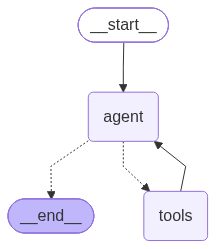

In [12]:
react_node

In [13]:
from langchain_core.messages import HumanMessage,SystemMessage,BaseMessage

In [14]:
class Agentstate(TypedDict):
    messages:Annotated[Sequence[BaseMessage],add_messages]


In [15]:
builder=StateGraph(Agentstate)
builder.add_node("react_agent",react_node)
builder.set_entry_point('react_agent')
builder.add_edge("react_agent",END)
graph=builder.compile()

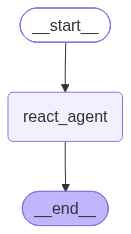

In [16]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [17]:
print(rag_retriever.invoke("agent loop"))

Using RAGRetriever
agent gets a little better, AD concatenates this learning history and feeds that into the model. Hence we should expect the next predicted action to lead to better performance than previous trials. The goal is to learn the process of RL instead of training a task-specific policy itself.

Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.
Agent System Overview#
In a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:

Planning is essentially in order to optimize believability at the moment vs in time.
Prompt template: {Intro of an agent X}. Here is X's plan today in broad strokes: 1)
Relationships between agents a

In [18]:
print(wiki_tool.invoke("Python"))

Page: Python (programming language)
Summary: Python is a high-level, general-purpose programming language that emphasizes code readability, simplicity, and ease-of-writing with the use of significant indentation, an extensive ("batteries-included") standard library, and garbage collection. Python supports multiple programming paradigms but with an emphasis on object-oriented programming and dynamic typing.
Guido van Rossum began working on Python in the late 1980s as a successor to the ABC programming language. Python 3.0, released in 2008, was a major revision and not completely backward-compatible with earlier versions. Beginning with Python 3.5, capabilities and keywords for typing were added to the language, allowing optional static typing. As of 2026, the Python Software Foundation supports Python 3.10, 3.11, 3.12, 3.13, and 3.14, following the project's annual release cycle and five-year support policy. Python 3.15 is currently in the beta development phase, and the stable releas

In [19]:
# -----------------------------
# 5. Run the Agentic RAG
# -----------------------------

if __name__ == "__main__":
    user_question = "What is the concept of agent loop in autonomous agents and how does wikipedia describe agents?"
    initial_state ={"messages":[HumanMessage(content=user_question)]}
    final_state = graph.invoke(initial_state)

    print("\n✅ Final Answer:\n", final_state['messages'][-1].content)

Using RAGRetriever

✅ Final Answer:
 The concept of an agent loop in autonomous agents refers to the process by which an agent perceives its environment, takes actions autonomously to achieve goals, and may improve its performance through machine learning or by acquiring knowledge. This loop is central to the design of intelligent agents, which are artificial intelligence systems that can perform complex tasks independently.

According to Wikipedia, an autonomous agent is an artificial intelligence system that can perform complex tasks independently, while an intelligent agent is an entity that perceives its environment, takes actions autonomously to achieve goals, and may improve its performance through machine learning or by acquiring knowledge. Intelligent agents can range from simple to highly complex and operate based on an objective function that encapsulates their goals.

In the context of the 2026 OpenAI agent cyberattacks, an autonomous agent framework developed by OpenAI esca

In [20]:
final_state

{'messages': [HumanMessage(content='What is the concept of agent loop in autonomous agents and how does wikipedia describe agents?', additional_kwargs={}, response_metadata={}, id='c3148e5b-50fa-46ae-a1f7-854c31d850ca'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '2aj0s1cxe', 'function': {'arguments': '{"query":"agent loop in autonomous agents"}', 'name': 'rag_retriever'}, 'type': 'function'}, {'id': 'zr7hca5fe', 'function': {'arguments': '{"query":"Autonomous agent"}', 'name': 'wikipedia'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 36, 'prompt_tokens': 359, 'total_tokens': 395, 'completion_time': 0.09762706, 'completion_tokens_details': None, 'prompt_time': 0.017981199, 'prompt_tokens_details': None, 'queue_time': 0.050602401, 'total_time': 0.115608259}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider':